<a href="https://colab.research.google.com/github/Amira-11/ar-navigation/blob/main/GymGuide_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GymGuide


# Course name : [Introduction to AI]
# Instructor : [D.Malek Alduhaymi]
# University : [PSAU]
# Department : [Electrical Engineering]

# Project team members



*   Lama Alotaibi
*   Amira Fahad
*   Shahad Talal







# Project Proposal

The objective of this project is to develop an AI-based image classification system that identifies gym equipment from a captured image and automatically provides a relevant YoiuTube tutorial explaining how to use rhe machine correctly without needing any external assistance. The system aims to assist beginners in learning proper exercise techniques in a simple and interactive way.

# Reference : https://github.com/tyl-99/gym-equipment-detector/tree/main

# Importing libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import numpy as np
import torchvision
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import Dataset
import json
import random
import os
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision.transforms import transforms
from tqdm import tqdm
from PIL import Image


# Dataset & Splitting

In [ ]:
class GymEquipmentDataset(Dataset):
    def __init__(self, transform=None):
        self.images_dir = '/content/drive/MyDrive/gym-equipment-detector-main/Datasets/'
        self.annotations = json.load(open('/content/drive/MyDrive/gym-equipment-detector-main/annotations.json'))
        self.transform = transform

        self.train_data, self.val_data, self.test_data = self.split_data()

    def split_data(self, split_ratio=(0.8,0.1,0.1)):
        dataset_size = len(self.annotations)
        train_size = int(split_ratio[0] * dataset_size)
        val_size = int(split_ratio[1] * dataset_size)
        test_size = dataset_size - train_size - val_size

        indices = list(range(dataset_size))
        random.shuffle(indices)


        split_indices = {
            'train': indices[:train_size],
            'val': indices[train_size:train_size + val_size],
            'test': indices[-test_size:]
        }

        splits = {}
        for split, idxs in split_indices.items():
            annotations = self._get_annotations([self.annotations[idx] for idx in idxs])
            splits[split] = annotations

        return splits['train'], splits['val'], splits['test']

    def _get_annotations(self, data):
        annotations = []
        for items in data:
            img_path =  items['file_name']
            image = Image.open(img_path).convert("RGB")
            image = self.transform(image)

            label = items['category_id']
            annotations.append((
                image,
                label
            ))
        return annotations





In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
dataset = GymEquipmentDataset(transform=transform)

#train_loader = DataLoader(dataset.train_data, batch_size=32, shuffle=True)
#val_loader = DataLoader(dataset.val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(dataset.test_data, batch_size=32, shuffle=False)



In [ ]:
class EquipmentModelRes34(nn.Module):
    def __init__(self, num_classes=22):
        super(EquipmentModelRes34, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(self._residual_block(self.in_channels, channels, stride))
            self.in_channels = channels
        return nn.Sequential(*layers)

    def _residual_block(self, in_channels, out_channels, stride):
        return ResidualBlock(in_channels, out_channels, stride)

    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.LeakyReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += self.shortcut(identity)
        out = self.relu(out)

        return out

In [ ]:

# class EquipmentModelRes34(nn.Module):

#     def __init__(self, num_classes=22):
#         super(EquipmentModelRes34, self).__init__()
#         self.in_channels = 64

#         self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
#         self.bn1 = nn.BatchNorm2d(64)
#         self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

#         self.layer1 = self._make_layer(64, 3, stride=1)

#         self.layer2 = self._make_layer(128, 4, stride=2)

#         self.layer3 = self._make_layer(256, 6, stride=2)

#         self.layer4 = self._make_layer(512, 3, stride=2)

#         self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
#         self.fc = nn.Linear(512, num_classes)

#     def _make_layer(self, channels, num_blocks, stride):
#         strides = [stride] + [1] * (num_blocks - 1)
#         layers = []
#         for stride in strides:
#             layers.append(nn.Sequential(
#                 nn.Conv2d(self.in_channels, channels, kernel_size=3, stride=stride, padding=1, bias=False),
#                 nn.BatchNorm2d(channels),
#                 nn.LeakyReLU(inplace=True),
#                 nn.Conv2d(channels, channels, kernel_size=3, stride=1, padding=1, bias=False),
#                 nn.BatchNorm2d(channels),
#                 nn.LeakyReLU(inplace=True)
#             ))
#             self.in_channels = channels
#         return nn.Sequential(*layers)

#     def forward(self, x):
#         x = self.pool1(F.relu(self.bn1(self.conv1(x))))

#         x = self.layer1(x)

#         x = self.layer2(x)

#         x = self.layer3(x)

#         x = self.layer4(x)

#         x = self.avgpool(x)

#         x = x.view(x.size(0), -1)

#         x = self.fc(x)
#         return x




In [ ]:
model = EquipmentModelRes34()

lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

# Training Setup

In [ ]:
epochs = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

train_accuracies = []
val_accuracies = []
wrong_predictions = []

torch.cuda.is_available()

False

In [ ]:
model = EquipmentModelRes34()
# 2 & 3. Load and map state dict (weights_only=True is a security best practice)
state_dict = torch.load('/content/drive/MyDrive/gym-equipment-detector-main/resmodel.pth', map_location='cpu', weights_only=True)
model.load_state_dict(state_dict)

<All keys matched successfully>

torch.Size([32, 3, 224, 224])


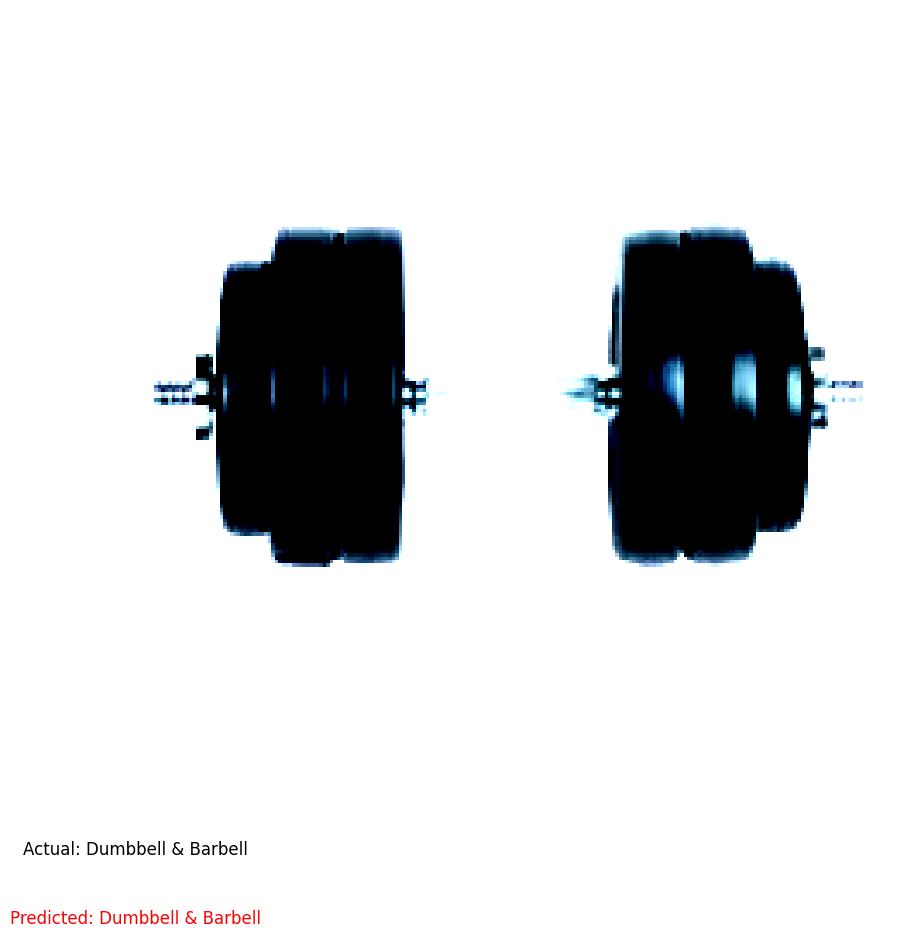

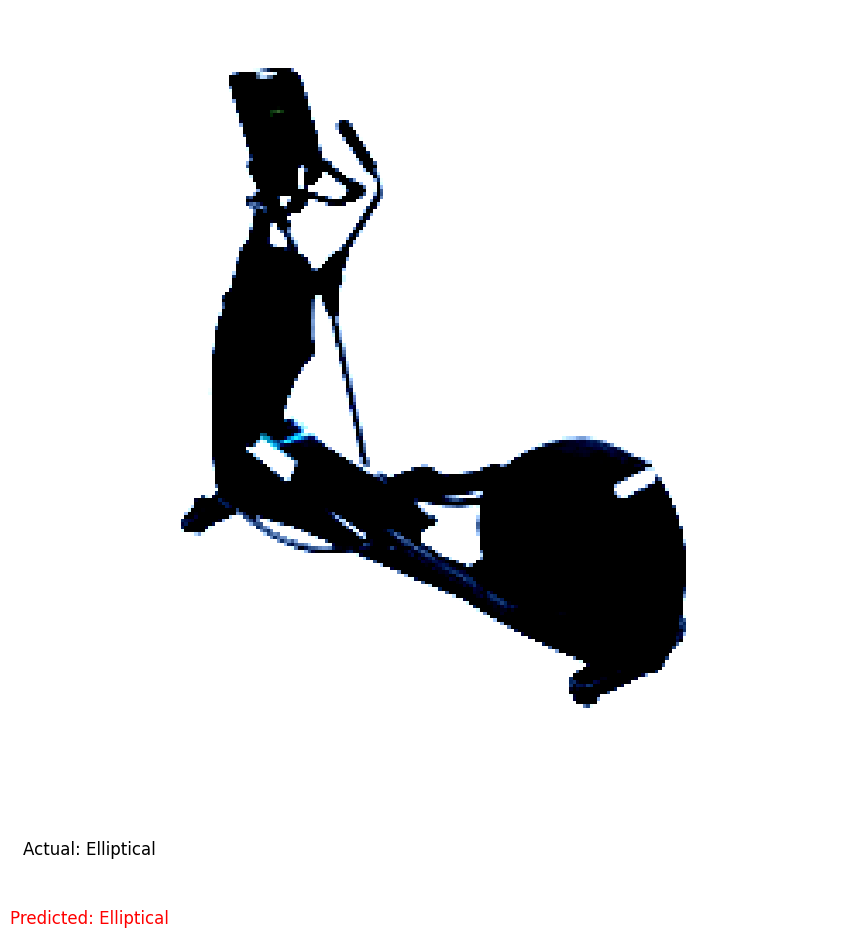

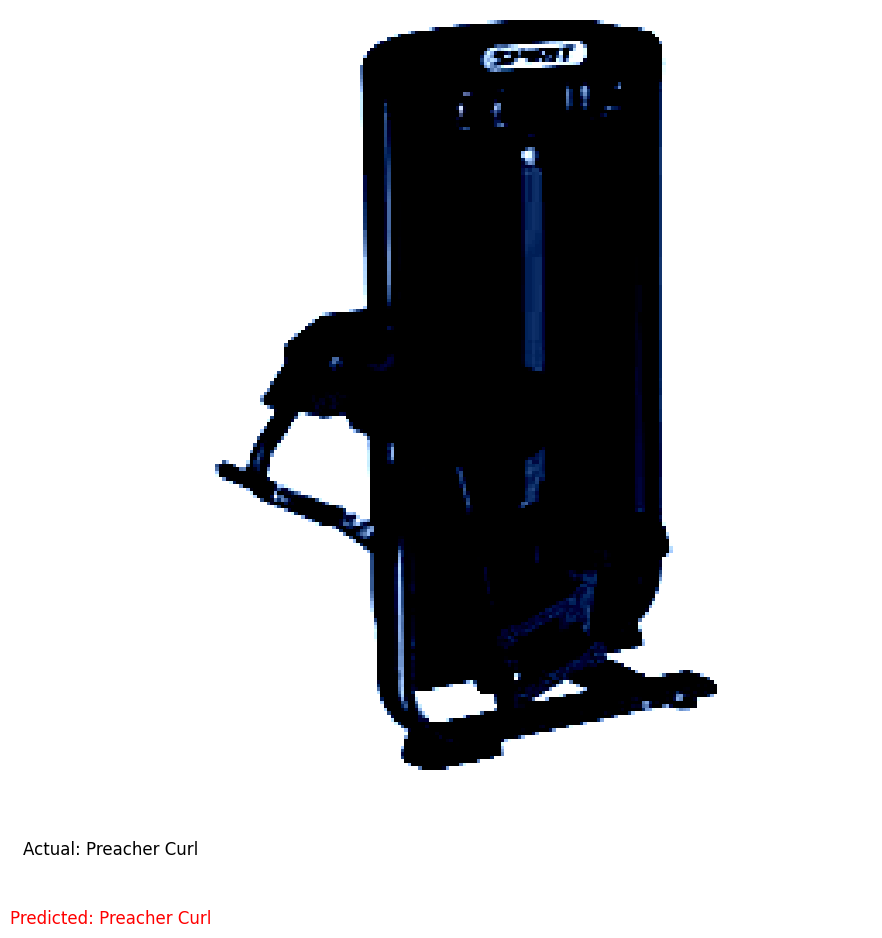

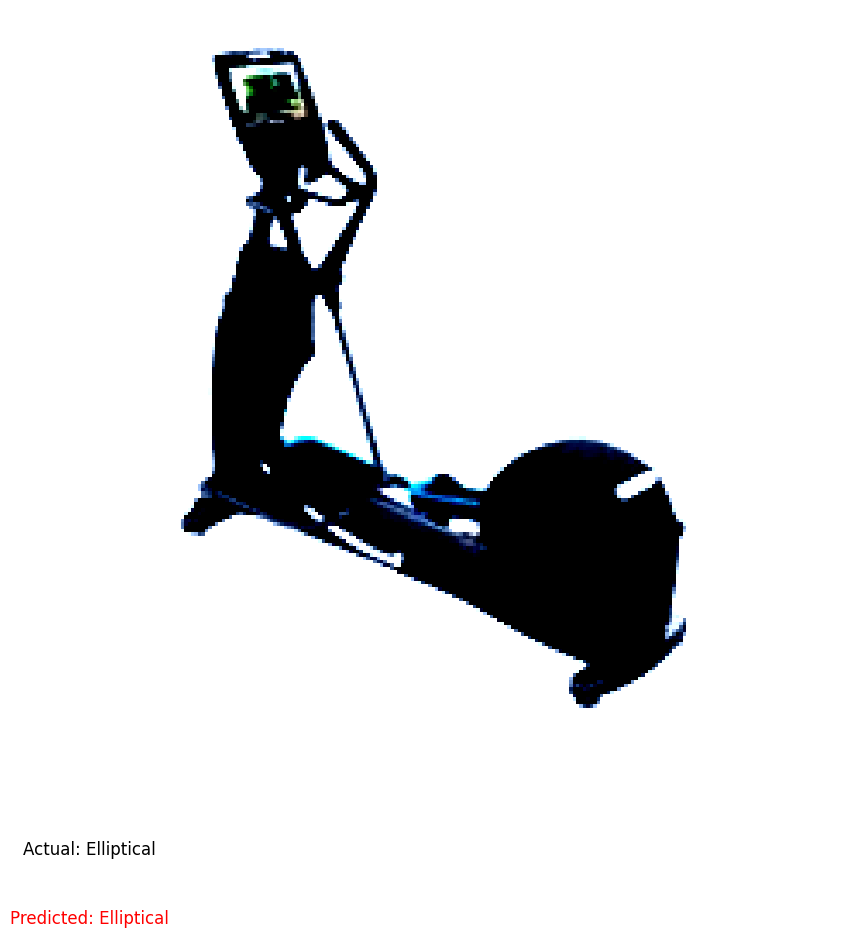

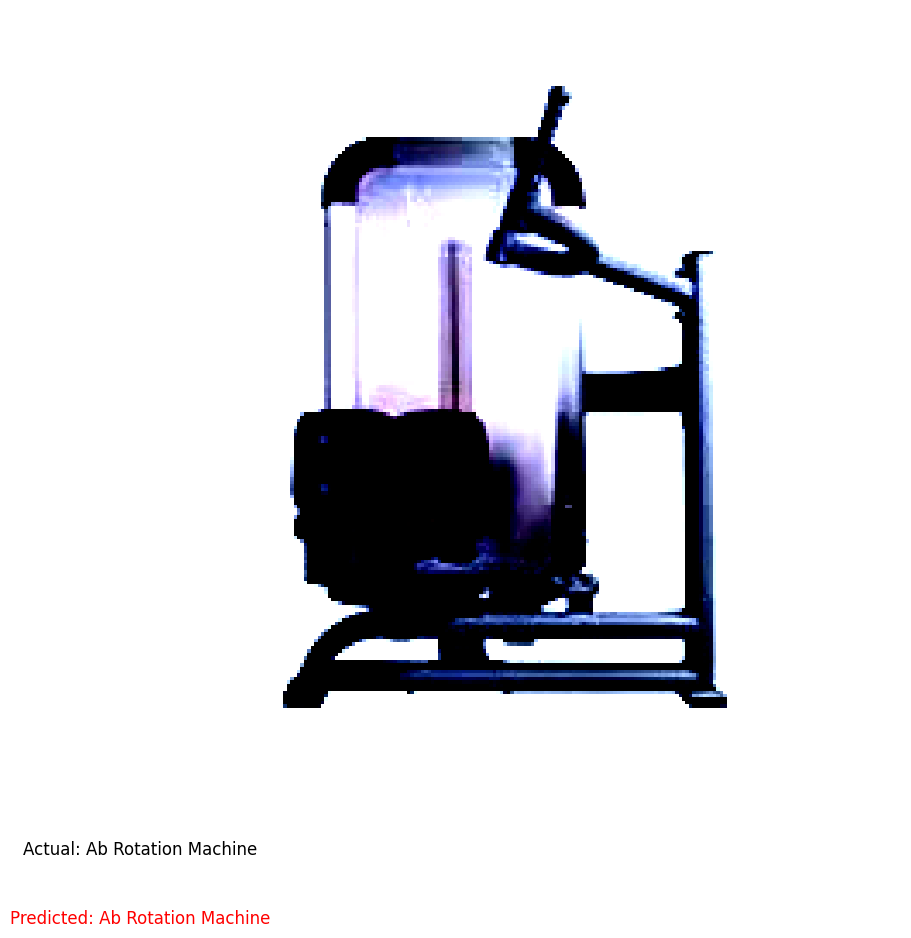

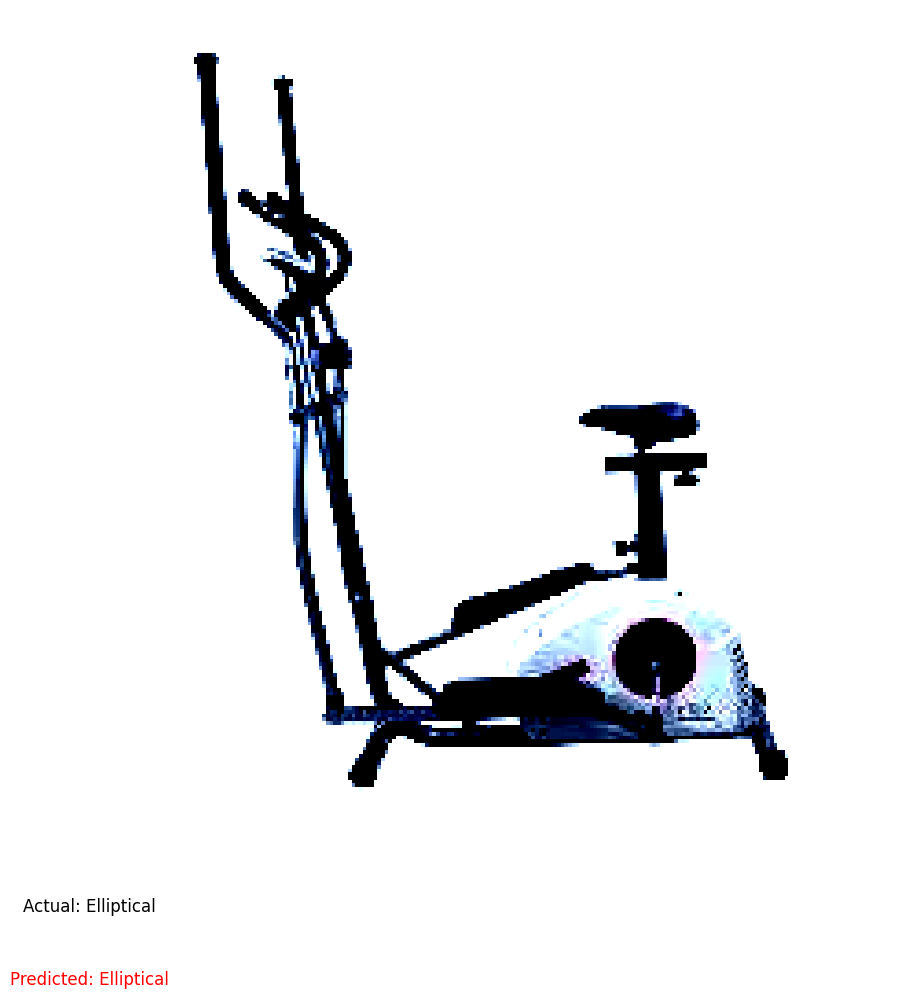

In [ ]:
classnames = [
    "Ab Rotation Machine",
    "Abs-Back Extension Dual Machine",
    "Chess Press Hammer",
    "Dips Machine",
    "Dumbbell & Barbell",
    "Elliptical",
    "Lat Pulldown-Seated Row Dual Machine",
    "Lateral Raise Machine",
    "Leg Abduction Machine",
    "Leg Press Machine",
    "Leg-Hamstring Curl Machine",
    "Pectoral Fly Machine",
    "Preacher Curl",
    "Shoulder Press Machine",
    "Smith & Multipurpose Machine",
    "Stationary Bike",
    "Treadmill"
]


model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)
labels = labels.to(device)
print(images.shape)
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

images_np = images.cpu().numpy()
labels_np = labels.cpu().numpy()
predicted_np = predicted.cpu().numpy()

random_indices = random.sample(range(len(images)), 6)



for i, idx in enumerate(random_indices):
    image = np.transpose(images_np[idx], (1, 2, 0))
    actual = classnames[labels_np[idx]]
    pred = classnames[predicted_np[idx]]

    fig = plt.figure( figsize=(10,10))
    axes=plt.gca()
    axes.imshow(image)
    axes.axis('off')

    axes.text(2, image.shape[0] + 20, f'Actual: {actual}', color='black', fontsize=12, ha='center', va='center')
    axes.text(2, image.shape[0] + 40, f'Predicted: {pred}', color='red', fontsize=12, ha='center', va='center')

plt.tight_layout()
plt.show()

# Testing & Result

Saving 5798724050749165434.jpg to 5798724050749165434 (1).jpg


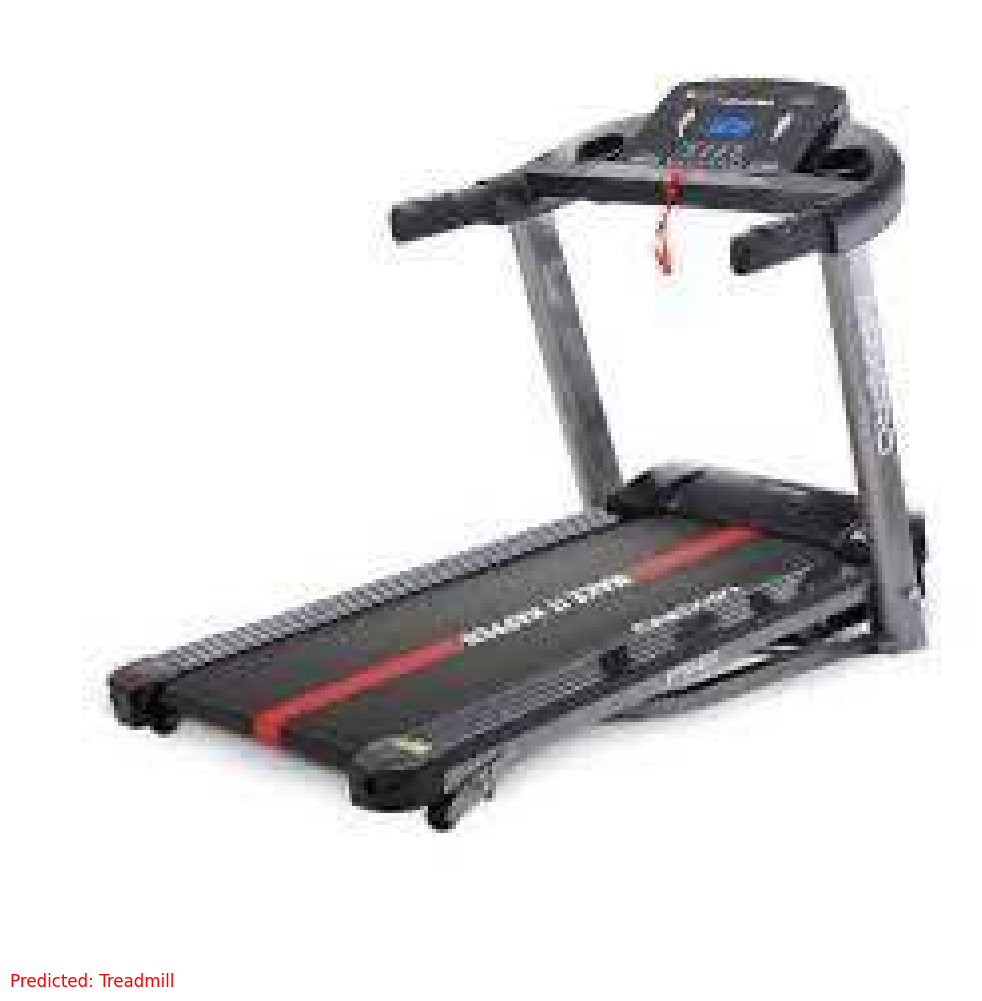

In [ ]:
from google.colab import files
from PIL import Image
import io

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

model.eval()
# سيظهر لك زر لاختيار الملف من جهازك
uploaded = files.upload()
for file_name in uploaded.keys():
    image_data = uploaded[file_name]
    img = Image.open(io.BytesIO(image_data))
    images=transform(img)
    images=images.to(device)
    with torch.no_grad():
        outputs = model(images.unsqueeze(0))
        _, predicted = torch.max(outputs, 1)

    predicted_np = predicted.cpu().numpy()
    pred = classnames[predicted_np[0]]
    fig = plt.figure( figsize=(10,10))
    axes=plt.gca()
    axes.imshow(img)
    axes.axis('off')
    axes.text(2, image.shape[0] + 20, f'Predicted: {pred}', color='red', fontsize=12, ha='center', va='center')
    plt.tight_layout()
    plt.show()




In [ ]:
import urllib.parse
from google.colab import output

# 1. Define your search query string
search_string = pred

# 2. Safely encode the string (e.g., converts spaces to %20)
encoded_query = urllib.parse.quote(search_string)

# 3. Replace 'x' with your encoded string
target_url = f"https://www.youtube.com/results?search_query={encoded_query}"

# 4. Use JavaScript to open it in a new browser tab
output.eval_js(f"window.open('{target_url}', '_blank');")